In [1]:
import os
import sys
import shutil

import h5py
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import yaml
from chroma import structure, plotting
from OpenMiChroM.CndbTools import cndbTools
import seaborn as sns
import pandas

from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable

plt.style.use("chroma.tex")

In [2]:
conditions = ["complete", "nucleolus", "lamina", "control"]

NUM_REPLICAS = 32
NUM_BEADS = 4980
NUCLEUS_RADIUS = 32.5
NUCLEOLI_RADIUS = (NUCLEUS_RADIUS) / 5 ** (1 / 3)
CHROMATIN_DENSITY = 0.30

OUTPUT_FOLDER = "/scratch/mm146/Polarization/3_IMR-90_hg38_fields-nb/4_analysis/energies/data"

In [3]:
color_palette = yaml.safe_load(open("../color-palette.yaml", "r"))

In [4]:
color_palette

{'complete': '#6abd45',
 'control': '#404040',
 'lamina': '#25C8FA',
 'nucleolus': '#ff0080'}

In [5]:
title = {
    "complete": r"$\in~$lamina",
    "nucleolus": r"$\notin~$lamina",
}

In [6]:
# for testing the figures:
mpl.rcParams["figure.dpi"] = 300

# Comparing IC


In [7]:
IC = {}
types = {}

columns = [
    "step",
    "FENE",
    "angles",
    "self_avoidance",
    "types",
    "IC",
    "nucleolus",
    "nucleolus_exclusion",
    "spherical_confinement",
    "conic_confinement",
    "lamina",
]

col_to_exclude = {
    "nucleolus": ["lamina"],
    "lamina": ["nucleolus"],
    "complete": [],
    "control": ["nucleolus", "lamina"],
}

for condition in conditions:
    IC[condition] = []
    types[condition] = []

    for replica in range(1, NUM_REPLICAS + 1):

        df = pandas.read_csv(
            f"/scratch/mm146/Polarization/3_IMR-90_hg38_fields-nb/3_sampling/{condition}/{replica}/energyComponents.txt",
            delimiter=",",
            skiprows=1,
            names=[
                x
                for x in columns
                if x not in col_to_exclude[condition]
            ],
        )
        IC[condition].extend(df["IC"].to_numpy())
        types[condition].extend(df["types"].to_numpy())

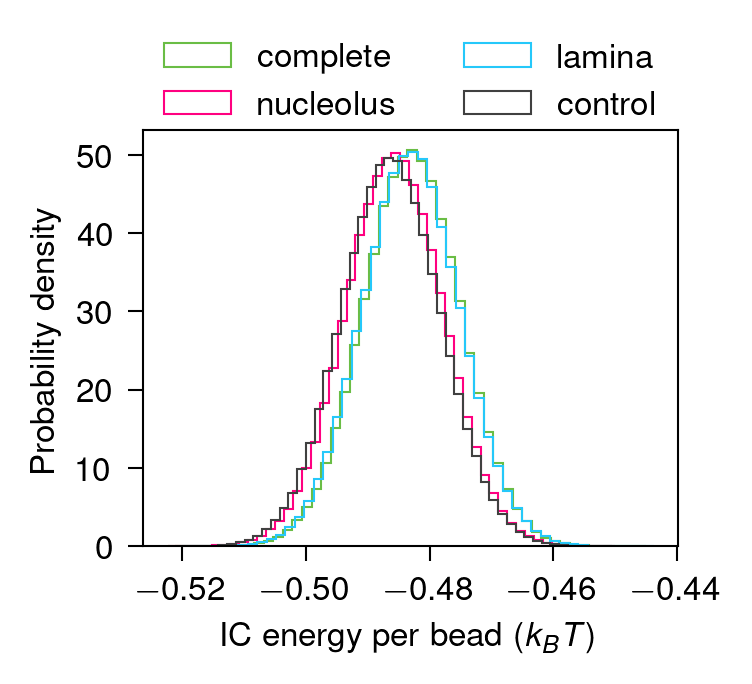

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(2.3, 1.8))

for condition in IC.keys():
    ax.hist(
        np.array(IC[condition]) / NUM_BEADS,
        bins=50,
        density=True,
        histtype="step",
        label=condition,
        color=color_palette[condition],
    )

ax.set_xlabel(r"IC energy per bead ($k_B T$)")
ax.set_ylabel("Probability density")
ax.legend(
    loc="lower center",
    frameon=False,
    ncols=2,
    bbox_to_anchor=(0.5, 0.95),
)

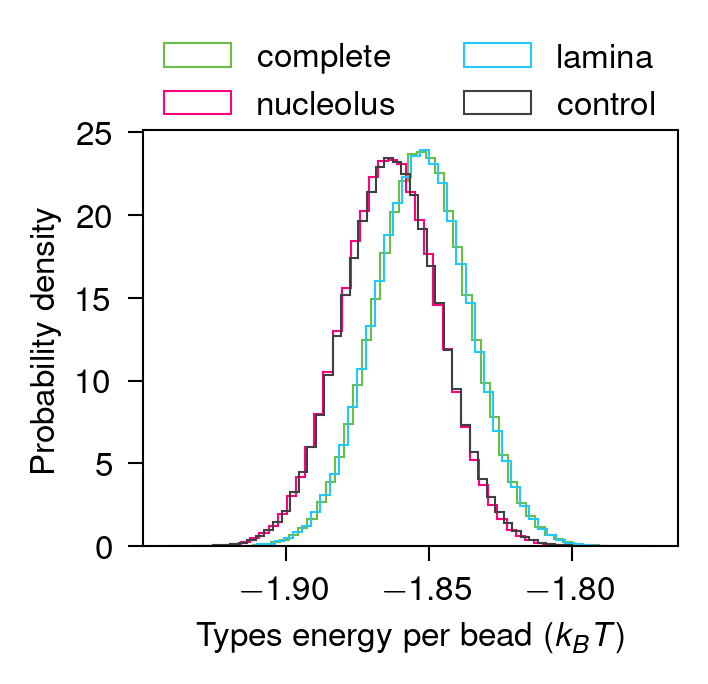

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(2.3, 1.8))

for condition in types.keys():
    ax.hist(
        np.array(types[condition]) / NUM_BEADS,
        bins=50,
        density=True,
        histtype="step",
        label=condition,
        color=color_palette[condition],
    )

ax.set_xlabel(r"Types energy per bead ($k_B T$)")
ax.set_ylabel("Probability density")
ax.legend(
    loc="lower center",
    frameon=False,
    ncols=2,
    bbox_to_anchor=(0.5, 0.95),
)

# Aggregate energy data


In [10]:
energies = {}
for condition in conditions:
    energies[condition] = {}
    for replica in range(1, NUM_REPLICAS + 1):
        with h5py.File(
            f"{OUTPUT_FOLDER}/{condition}/contact-energies-replica{replica}.h5",
            "r",
        ) as f:
            for key in f.keys():
                if key not in energies[condition]:
                    energies[condition][key] = np.array([])
                energies[condition][key] = np.concatenate(
                    (
                        energies[condition][key],
                        f[key][()],
                    ),
                    axis=0,
                )
            energies[condition]["all"] = np.sum(
                np.array(
                    [
                        energies[condition][k]
                        for k in energies[condition]
                        if k != "all"
                    ]
                ),
                axis=0,
            )

In [11]:
with h5py.File(
    os.path.join(OUTPUT_FOLDER, "contact-energies-aggregated.h5"), "w"
) as f:
    for condition in energies.keys():
        grp = f.create_group(condition)
        for key in energies[condition].keys():
            grp.create_dataset(key, data=energies[condition][key])

# Plotting contact energies


In [18]:
energies = {}
with h5py.File(
    os.path.join(OUTPUT_FOLDER, "contact-energies-aggregated.h5"), "r"
) as f:
    for condition in f.keys():
        energies[condition] = {}
        for key in f[condition].keys():
            energies[condition][key] = f[condition][key][
                ()
            ]  # / NUM_BEADS

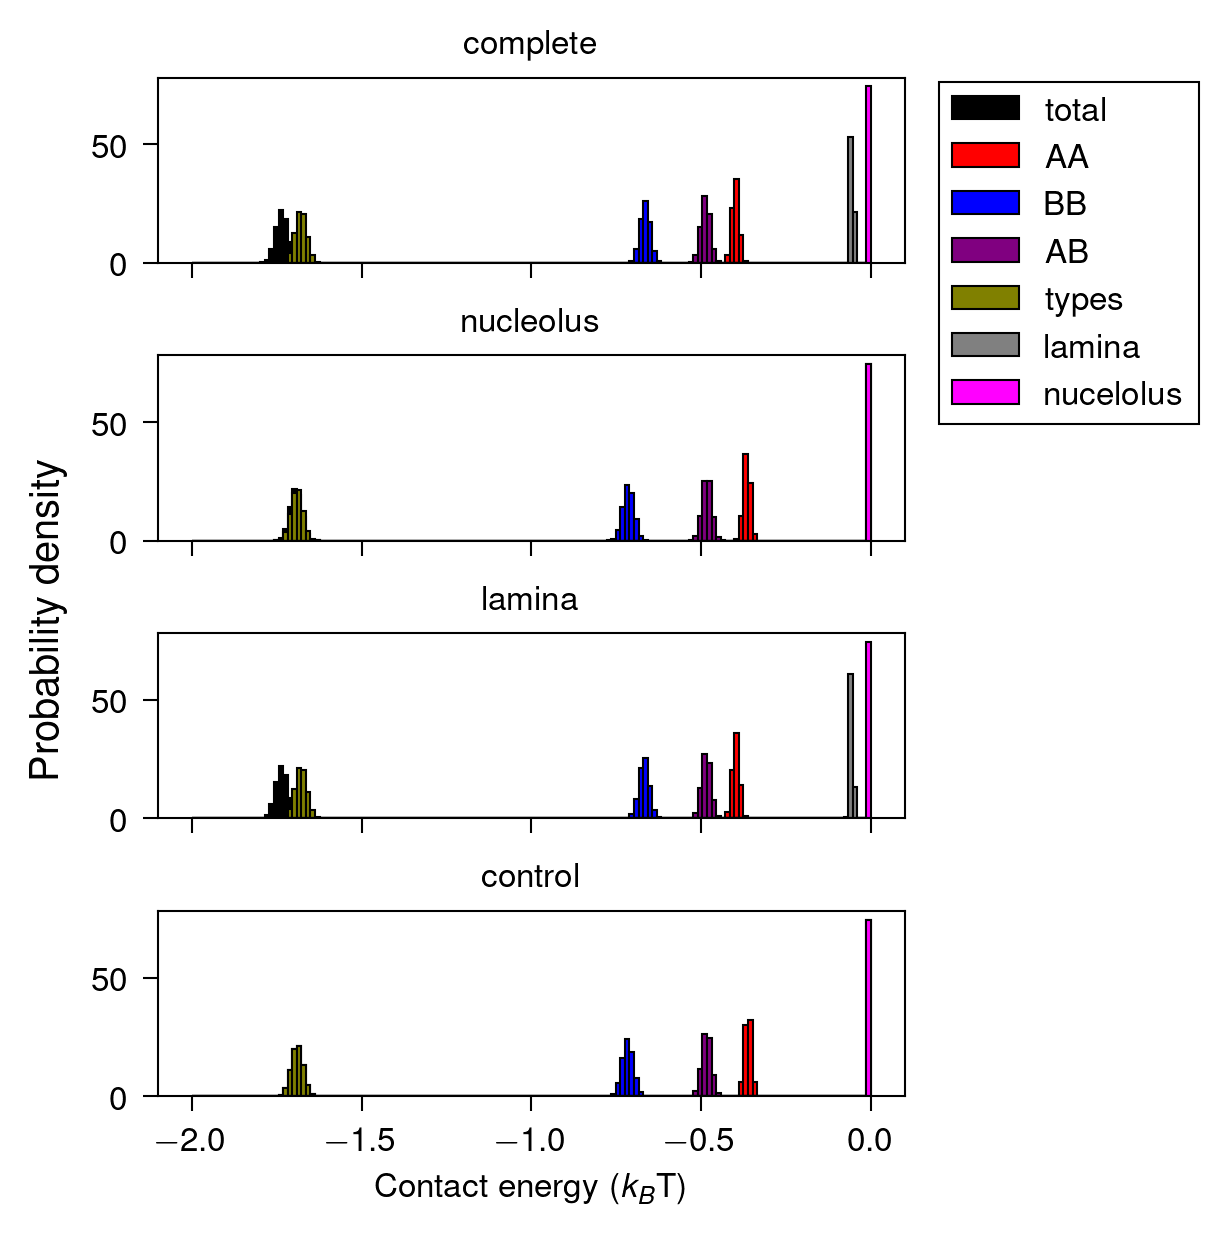

In [8]:
fig, ax = plt.subplots(
    len(conditions),
    1,
    figsize=(
        3,
        1 * len(conditions),
    ),
    constrained_layout=True,
    sharex=True,
    sharey=True,
)

bins = np.linspace(-2, -0, 150)

for i, condition in enumerate(conditions):
    ax[i].set_title(condition)

    ax[i].hist(
        energies[condition]["all"],
        bins=bins,
        density=True,
        # histtype="step",
        label="total",
        color="black",
    )
    ax[i].hist(
        energies[condition]["AA"],
        bins=bins,
        density=True,
        # histtype="step",
        label="AA",
        color="red",
    )
    ax[i].hist(
        energies[condition]["BB"],
        bins=bins,
        density=True,
        # histtype="step",
        label="BB",
        color="blue",
    )
    ax[i].hist(
        energies[condition]["AB"],
        bins=bins,
        density=True,
        # histtype="step",
        label="AB",
        color="purple",
    )
    ax[i].hist(
        np.sum(
            [
                energies[condition][key]
                for key in ["AA", "AB", "BB", "AN", "BN", "NN"]
            ],
            axis=0,
        ),
        bins=bins,
        density=True,
        # histtype="step",
        label="types",
        color="olive",
    )
    ax[i].hist(
        energies[condition]["lamina"],
        bins=bins,
        density=True,
        # histtype="step",
        label="lamina",
        color="gray",
    )
    ax[i].hist(
        energies[condition]["nucleolus"],
        bins=bins,
        density=True,
        # histtype="step",
        label="nucelolus",
        color="magenta",
    )

    # ax[i].set_ylim(0, 0.010)

fig.supylabel("Probability density")
ax[-1].set_xlabel("Contact energy ($k_B$T)")
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    bbox_to_anchor=(1.005, 0.959),
    loc="upper left",
    fontsize=8,
    ncol=1,
)

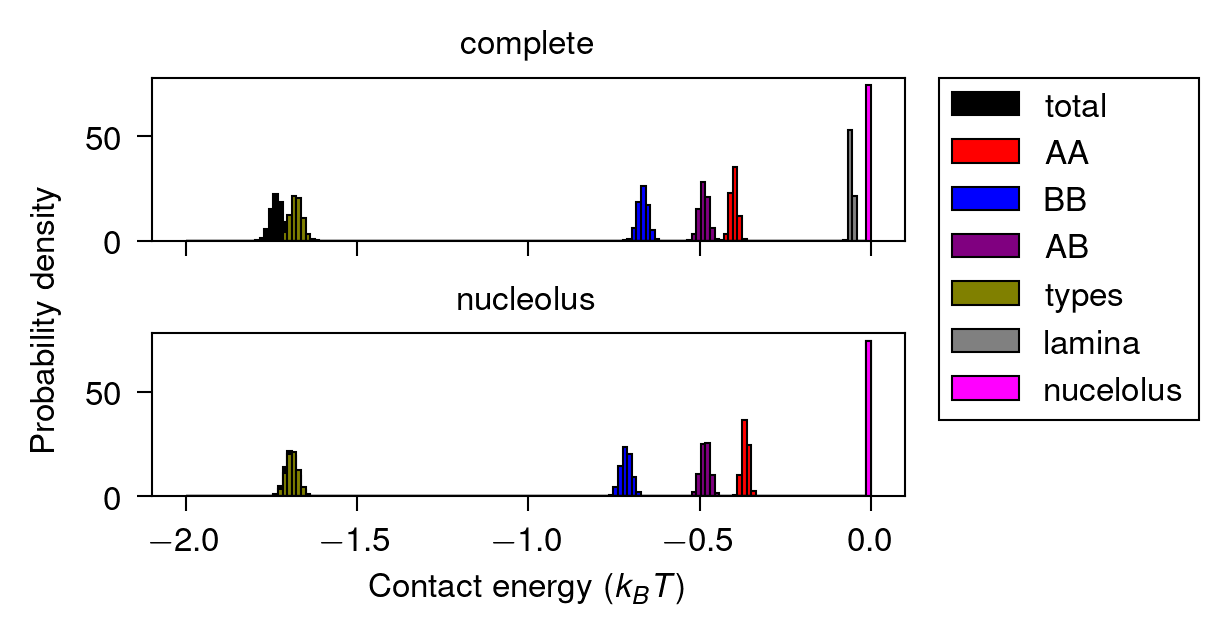

In [9]:
chosen_conditions = [
    "complete",
    "nucleolus",
]

fig, ax = plt.subplots(
    len(chosen_conditions),
    1,
    figsize=(
        3,
        1 * len(chosen_conditions),
    ),
    constrained_layout=True,
    sharex=True,
    sharey=True,
)

bins = np.linspace(-2, -0, 150)

for i, condition in enumerate(chosen_conditions):
    ax[i].set_title(condition)

    ax[i].hist(
        energies[condition]["all"],
        bins=bins,
        density=True,
        # histtype="step",
        label="total",
        color="black",
    )
    ax[i].hist(
        energies[condition]["AA"],
        bins=bins,
        density=True,
        # histtype="step",
        label="AA",
        color="red",
    )
    ax[i].hist(
        energies[condition]["BB"],
        bins=bins,
        density=True,
        # histtype="step",
        label="BB",
        color="blue",
    )
    ax[i].hist(
        energies[condition]["AB"],
        bins=bins,
        density=True,
        # histtype="step",
        label="AB",
        color="purple",
    )
    ax[i].hist(
        np.sum(
            [
                energies[condition][key]
                for key in ["AA", "AB", "BB", "AN", "BN", "NN"]
            ],
            axis=0,
        ),
        bins=bins,
        density=True,
        # histtype="step",
        label="types",
        color="olive",
    )
    ax[i].hist(
        energies[condition]["lamina"],
        bins=bins,
        density=True,
        # histtype="step",
        label="lamina",
        color="gray",
    )
    ax[i].hist(
        energies[condition]["nucleolus"],
        bins=bins,
        density=True,
        # histtype="step",
        label="nucelolus",
        color="magenta",
    )

    # ax[i].set_ylim(0, 0.010)

fig.supylabel("Probability density", fontsize=8)
ax[-1].set_xlabel("Contact energy ($k_BT$)")
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    bbox_to_anchor=(1.005, 0.925),
    loc="upper left",
    fontsize=8,
    ncol=1,
)

Text(0.5, 0, 'Contact energy ($k_BT$)')

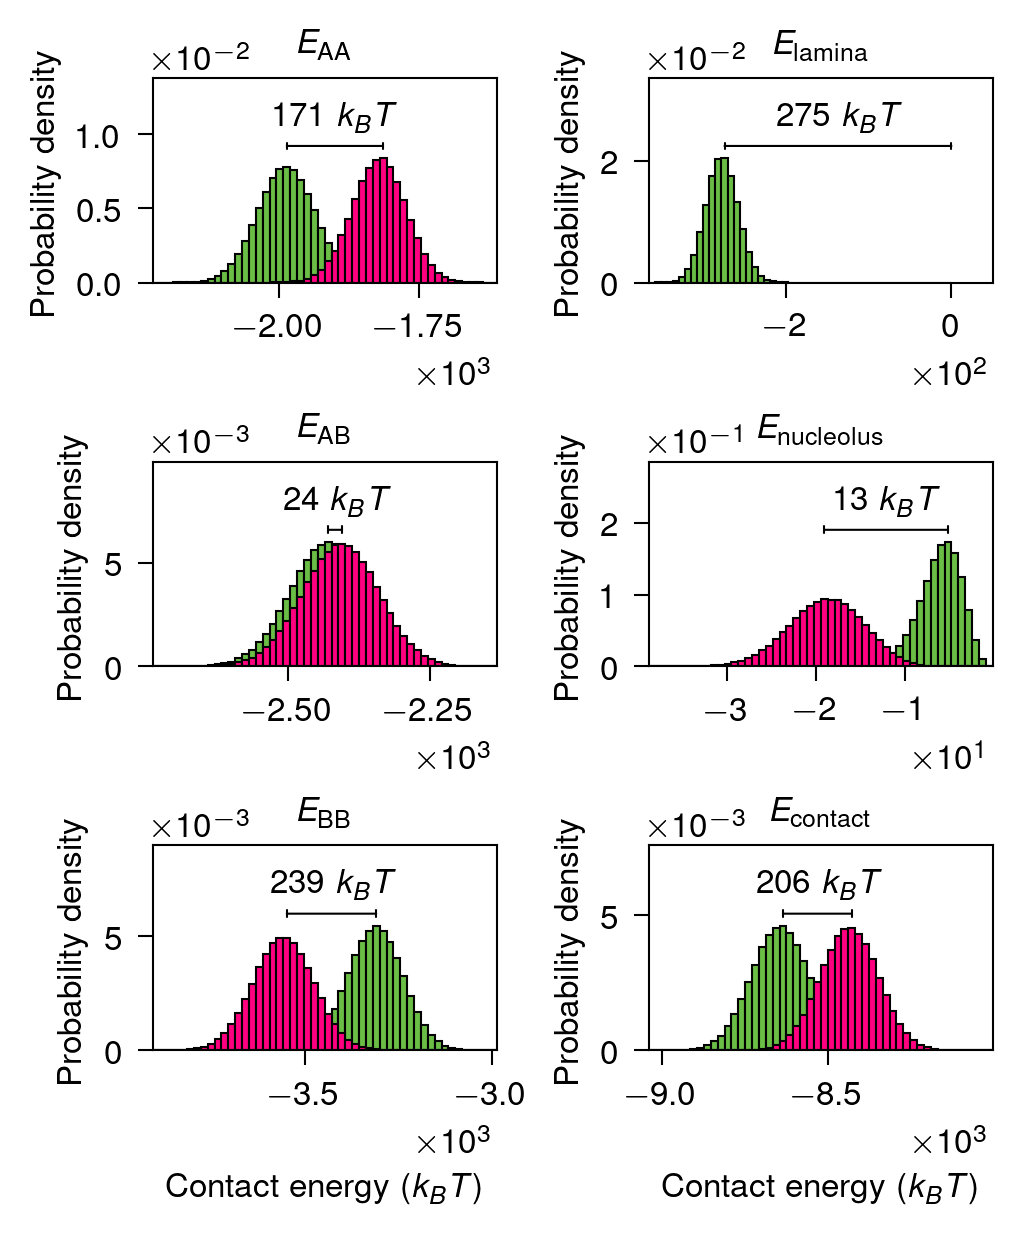

In [30]:
chosen_conditions = [
    "complete",
    "nucleolus",
]

labels = ["AA", "AB", "BB", "lamina", "nucleolus", "all"]
colors = ["red", "purple", "blue", "gray", "magenta", "black"]

fig, ax = plt.subplots(
    len(labels) // 2,
    2,
    figsize=(
        3.2,
        4.0,
    ),
    constrained_layout=True,
    sharex=False,
    sharey=False,
)

bins = 51

ax = np.concatenate((ax[:, 0], ax[:, 1]))

for i, label in enumerate(labels):
    vmin = min(
        np.min(energies[condition][label])
        for condition in chosen_conditions
    )
    vmax = max(
        np.max(energies[condition][label])
        for condition in chosen_conditions
    )
    bins = np.linspace(vmin, vmax, 51)

    ymax = []
    x_ymax = []
    for condition in chosen_conditions:
        hist, bin_edges = np.histogram(
            energies[condition][label],
            bins=bins,
            density=True,
        )
        if not (label == "lamina" and condition == "nucleolus"):
            ymax.append(np.max(hist))
            x_ymax.append(
                ((bin_edges[:-1] + bin_edges[1:]) / 2)[
                    np.argmax(hist)
                ]
            )
            ax[i].bar(
                (bin_edges[:-1] + bin_edges[1:]) / 2,
                hist,
                width=bin_edges[1] - bin_edges[0],
                label=title[condition],
                color=color_palette[condition],
            )
            # ax[i].plot(
            #     (bin_edges[:-1] + bin_edges[1:]) / 2,
            #     hist,
            #     label=title[condition],
            #     color=color_palette[condition],
            # )
        else:
            ymax.append(0)
            x_ymax.append(0)
            vmax = 50

    # annotate the energy difference of the peaks
    energy_diff = np.abs(x_ymax[0] - x_ymax[1])
    annot_y = 1.1 * max(ymax)

    ax[i].annotate(
        "",
        xy=(x_ymax[0], annot_y),
        xytext=(x_ymax[1], annot_y),
        arrowprops=dict(
            arrowstyle="|-|,widthA=0.1, widthB=0.1",
            color="black",
            lw=0.5,
            shrinkA=0,
            shrinkB=0,
        ),
    )

    mid_x = (x_ymax[0] + x_ymax[1]) / 2
    sci_notation = f"{energy_diff:.1e}"
    mantissa, exponent = sci_notation.split("e")
    ax[i].text(
        mid_x,
        annot_y * 1.1,
        f"${int(energy_diff)}$ $k_BT$",
        # f"${mantissa}\\times10^{{{int(exponent)}}}$ $k_BT$",
        ha="center",
        va="bottom",
        fontsize=8,
    )

    ax[i].set_title(
        f"$E_\\mathrm{{{label if label != 'all' else 'contact'}}}$"
    )
    ax[i].set_ylim(bottom=0, top=annot_y * 1.5)
    ax[i].set_xlim(vmin, vmax)
    ax[i].set_ylabel("Probability density", fontsize=8)

    formatter = mpl.ticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-1, 1))
    ax[i].yaxis.set_major_formatter(formatter)

    formatter = mpl.ticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-1, 1))
    ax[i].xaxis.set_major_formatter(formatter)

ax[-1].set_xlabel("Contact energy ($k_BT$)", labelpad=15)
ax[2].set_xlabel("Contact energy ($k_BT$)", labelpad=15)
# ax[-1].set_xlabel("Contact energy per bead ($k_BT$)")
# ax[2].set_xlabel("Contact energy per bead ($k_BT$)")

# handles, labels = ax[0].get_legend_handles_labels()

# fig.legend(
#     handles,
#     labels,
#     bbox_to_anchor=(1.005, 0.925),
#     loc="upper left",
#     fontsize=8,
#     ncol=1,
# )